In [28]:
import yfinance
import matplotlib
import matplotlib.pyplot as plt
import torch
import numpy as np
import sys 
import os
# Añadir la carpeta src al path
sys.path.append(os.path.abspath("../src"))
from constructor_sinu import set_device
from mlp import BaseSinuRNN, TensorLoader

In [61]:
class GRUMulti(torch.nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, H=20, dropout=0.0):
        super().__init__()
        self.gru = torch.nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.head = torch.nn.Linear(hidden_size, H)

    def forward(self, x):
        out, _ = self.gru(x)         # (B,L,Hid)
        h_last = out[:, -1, :]       # (B,Hid)
        y = self.head(h_last)        # (B,H)
        return y

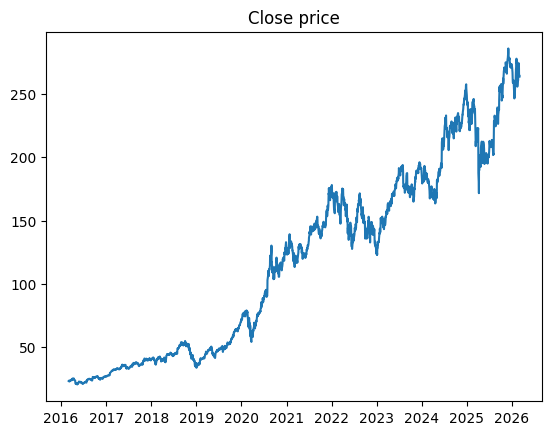

In [62]:

data = yfinance.Ticker("AAPL")
one_year = data.history(period="10y")

one_year = one_year[["Close"]].iloc[:-1]
a = int(len(one_year)*0.7)
train = one_year.iloc[:a]
test  = one_year.iloc[a:]

plt.plot(one_year.index, one_year["Close"])
plt.title("Close price")
plt.show()

In [63]:
from torch import nn
class TensorLoader:

    def __init__(self, X, Y, bs=None, shuffle=True):
        self.X = X
        self.Y = Y
        self.len = len(X)

        self.bs = bs if bs else self.len
        self.shuffle = shuffle

        self.nbatch = (self.len + self.bs - 1) // self.bs
        self.device = X.device

        self.reset()

    def reset(self):
        self.p0 = 0
        if self.shuffle:
            self.idx = torch.randperm(self.len, device=self.device)
        else:
            self.idx = None

    def next(self):

        pf = min(self.p0 + self.bs, self.len)

        if self.idx is None:
            xb = self.X[self.p0:pf]
            yb = self.Y[self.p0:pf]
        else:
            ids = self.idx[self.p0:pf]
            xb = self.X[ids]
            yb = self.Y[ids]

        self.p0 = pf

        if self.p0 >= self.len:
            self.reset()

        return xb, yb


    @staticmethod
    def train(X, Y, model, loss_fn, optimizer,
              epochs=200, bs=64, device="cuda", trace=20):

        # mover dataset a GPU una sola vez
        X = X.to(device)
        Y = Y.to(device)

        dataloader = TensorLoader(X, Y, bs=bs, shuffle=True)

        model = model.to(device)

        for e in range(epochs):

            model.train()
            acum_loss = 0

            for _ in range(dataloader.nbatch):

                xb, yb = dataloader.next()

                optimizer.zero_grad(set_to_none=True)

                pred = model(xb)
                loss = loss_fn(pred, yb)

                loss.backward()

                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

                optimizer.step()

                acum_loss += loss.item()

            if (e+1) % trace == 0:
                print(f"loss: {acum_loss/dataloader.nbatch:>10f} [{e+1:>5d}/{epochs:>5d}]")

In [64]:
@torch.no_grad()
def predict_H(model, seed_series, L, device="cpu"):
    model.eval()
    seed = torch.tensor(seed_series[-L:], dtype=torch.float32).view(1, L, 1).to(device)
    yhat = model(seed).squeeze(0).detach().cpu().numpy()  # (H,)
    return yhat

def make_windows_multistep(series, L=30, H=20):
    X, Y = [], []
    T = len(series)
    for t in range(T - L - H + 1):
        X.append(series[t:t+L])
        Y.append(series[t+L:t+L+H])  # vector de H pasos
    X = np.array(X, dtype=np.float32)[:, :, None]   # (N,L,1)
    Y = np.array(Y, dtype=np.float32)               # (N,H)
    return X, Y


In [82]:
device = set_device()

def make_windows_multistep(series, L=30, H=20):
    X, Y = [], []
    T = len(series)
    for t in range(T - L - H + 1):
        X.append(series[t:t+L])
        Y.append(series[t+L:t+L+H])
    X = np.array(X, dtype=np.float32)[:, :, None]
    Y = np.array(Y, dtype=np.float32)
    return X, Y

# 1) prices -> log-returns
p = train["Close"].values.astype(np.float32)
logp = np.log(p + 1e-8)
r = np.diff(logp)                          # length T-1

# 2) normalize returns (much more stable)
mu_r = r.mean()
sig_r = r.std() + 1e-8
r_z = (r - mu_r) / sig_r

L, H = 30, 20
X_np, Y_np = make_windows_multistep(r_z, L=L, H=H)
x = torch.tensor(X_np)
y = torch.tensor(Y_np)

# train con tu TensorLoader + GRUMulti igual que ya tienes

model = GRUMulti(hidden_size=64, num_layers=5, H=H, dropout=0.1)

loss_fn = torch.nn.MSELoss()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

TensorLoader.train(
    x, y,
    model,
    loss_fn,
    optimizer,
    epochs=400,
    bs=64,
    device=device,
    trace=20
)



Using cuda device
loss:   0.960631 [   20/  400]
loss:   0.758256 [   40/  400]
loss:   0.605676 [   60/  400]
loss:   0.442637 [   80/  400]
loss:   0.311240 [  100/  400]
loss:   0.230490 [  120/  400]
loss:   0.139203 [  140/  400]
loss:   0.096249 [  160/  400]
loss:   0.075479 [  180/  400]
loss:   0.061953 [  200/  400]
loss:   0.054413 [  220/  400]
loss:   0.048614 [  240/  400]
loss:   0.042770 [  260/  400]
loss:   0.040397 [  280/  400]
loss:   0.036690 [  300/  400]
loss:   0.034795 [  320/  400]
loss:   0.032489 [  340/  400]
loss:   0.030268 [  360/  400]
loss:   0.028992 [  380/  400]
loss:   0.026934 [  400/  400]


pred: [146.72221 147.72948 145.5709  142.428   142.09703] ... [316.3179  318.0762  319.05585 319.0753  318.4072 ]
true: [143.23492432 143.82637024 148.8732605  151.63327026 149.43510437] ... [274.23001099 272.95001221 264.17999268 264.72000122 263.75      ]


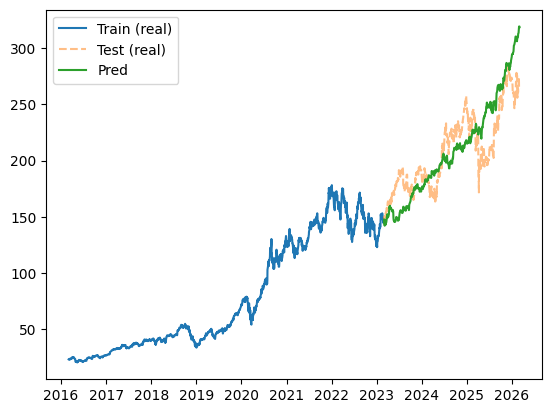

In [83]:
@torch.no_grad()
def predict_blocks(model, seed_series, L, total_steps, H, device="cuda"):
    model.eval()
    seed = list(seed_series.astype(np.float32))
    preds = []
    while len(preds) < total_steps:
        window = torch.tensor(seed[-L:], dtype=torch.float32, device=device).view(1, L, 1)
        block = model(window).squeeze(0).detach().cpu().numpy().tolist()
        need = total_steps - len(preds)
        block = block[:need]
        preds.extend(block)
        seed.extend(block)
    return np.array(preds, dtype=np.float32)

# predice returns normalizados
pred_r_z = predict_blocks(model, r_z, L=L, total_steps=len(test), H=H, device=device)

# desnormaliza returns
pred_r = pred_r_z * sig_r + mu_r

# reconstruye precios desde el último precio del train
p0 = train["Close"].values.astype(np.float32)[-1]
logp0 = np.log(p0 + 1e-8)
r_train = np.diff(np.log(train["Close"].values.astype(np.float32) + 1e-8))
r_mean_train = r_train.mean()

pred_r = pred_r - pred_r.mean() + r_mean_train
logp_pred = logp0 + np.cumsum(pred_r)
pred_price = np.exp(logp_pred)
print("pred:", pred_price[:5], "...", pred_price[-5:])
print("true:", test["Close"].values[:5], "...", test["Close"].values[-5:])

plt.plot(train.index, train["Close"].values, label="Train (real)")
plt.plot(test.index, test["Close"].values, "--", alpha=0.5, label="Test (real)")
plt.plot(test.index, pred_price, label="Pred")
plt.legend()
plt.show()

In [84]:
torch.save(model.state_dict(), "gru_model.pt")